In [43]:
import pandas as pd
import numpy as np

In [44]:
billings = pd.read_csv("../data/01_raw/raw_billings.csv")
renewal_calls = pd.read_csv("../data/01_raw/raw_renewal_calls.csv")
emails = pd.read_csv("../data/01_raw/raw_emails.csv")
cc_calls = pd.read_csv("../data/01_raw/raw_cc_calls.csv")


C:\Users\shrey\AppData\Local\Temp\ipykernel_39580\1969676906.py:1: DtypeWarning: Columns (15,16,19,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  billings = pd.read_csv("../data/01_raw/raw_billings.csv")
C:\Users\shrey\AppData\Local\Temp\ipykernel_39580\1969676906.py:2: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  renewal_calls = pd.read_csv("../data/01_raw/raw_renewal_calls.csv")
C:\Users\shrey\AppData\Local\Temp\ipykernel_39580\1969676906.py:3: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  emails = pd.read_csv("../data/01_raw/raw_emails.csv")


In [45]:
print("Billings:", billings.shape)
print("Renewal Calls:", renewal_calls.shape)
print("Emails:", emails.shape)
print("cc_calls:", cc_calls.shape)

Billings: (122082, 59)
Renewal Calls: (186534, 41)
Emails: (123389, 27)
cc_calls: (32882, 33)


In [46]:
billings.columns

Index(['Co_Ref', 'Renewal_Month', 'Connection_Net', 'Connection_Qty',
       'Discount_Amount', 'Sustainability_Score', 'Total_Renewal_Score_New',
       'Starting_Connection_Net', 'Starting_Connection_Qty',
       'Last_Years_Price', 'Last_Years_Date_Paid', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band',
       'Prospect_Renewal_Date', 'Closed_Date', 'Prospect_Status',
       'Starting_Net', 'Starting_Vat', 'Starting_Gross',
       'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net',
       'Gross', 'Membership_Net', 'Package_

In [47]:
common_cols = set(billings.columns).intersection(set(renewal_calls.columns))
print(common_cols)


{'Co_Ref'}


In [48]:
billings[["Co_Ref", "Prospect_Renewal_Date"]].head()

,Co_Ref,Prospect_Renewal_Date
0,VT6174,05-11-2024
1,VD3828,09-08-2025
2,DV8120,12-03-2025
3,EZ9894,29-06-2025
4,FA8957,25-03-2025


In [49]:
renewal_calls[["Co_Ref", "Call_Date"]].head()

,Co_Ref,Call_Date
0,UB0899,29-01-2025
1,HN5141,26-02-2025
2,BP5009,24-01-2025
3,XP8119,09-06-2025
4,ZL7978,20-08-2024


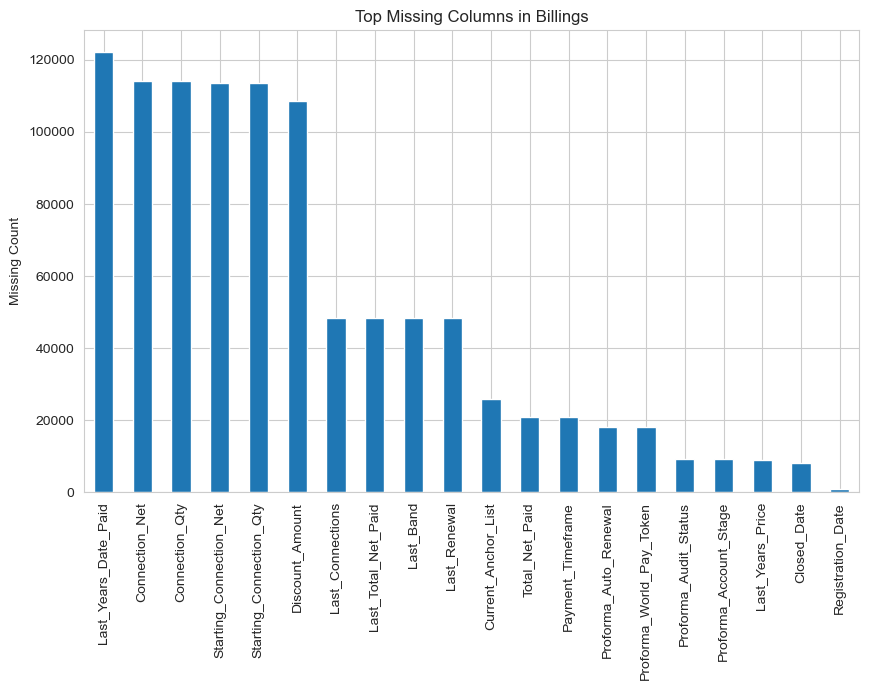

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
missing = billings.isnull().sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
missing.plot(kind="bar")
plt.title("Top Missing Columns in Billings")
plt.ylabel("Missing Count")
plt.show()

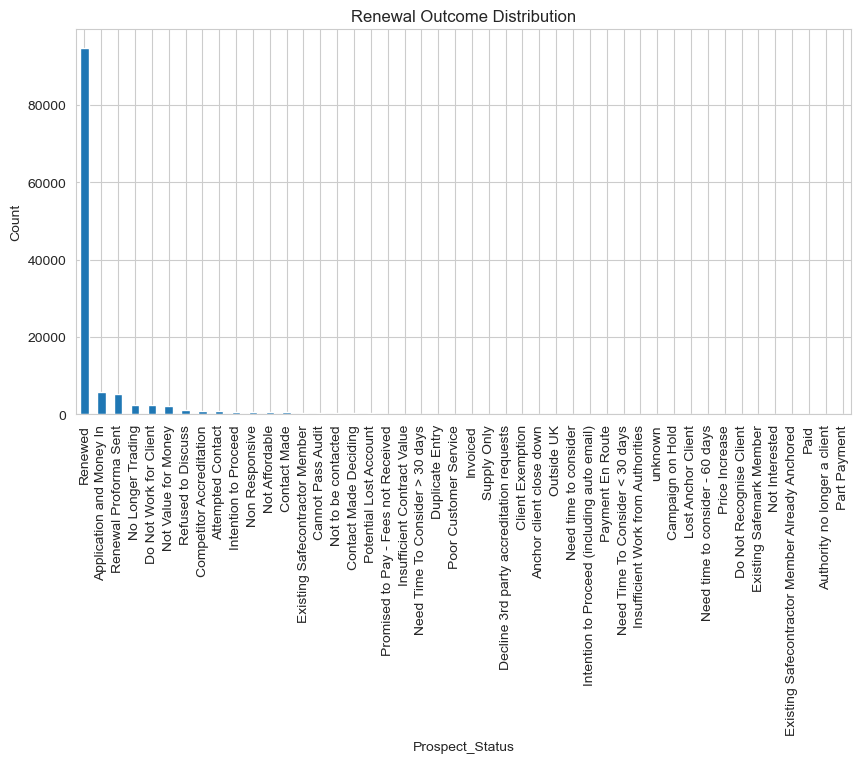

In [55]:
plt.figure(figsize=(10,5))
billings["Prospect_Status"].value_counts().plot(kind="bar")
plt.title("Renewal Outcome Distribution")
plt.ylabel("Count")
plt.show()

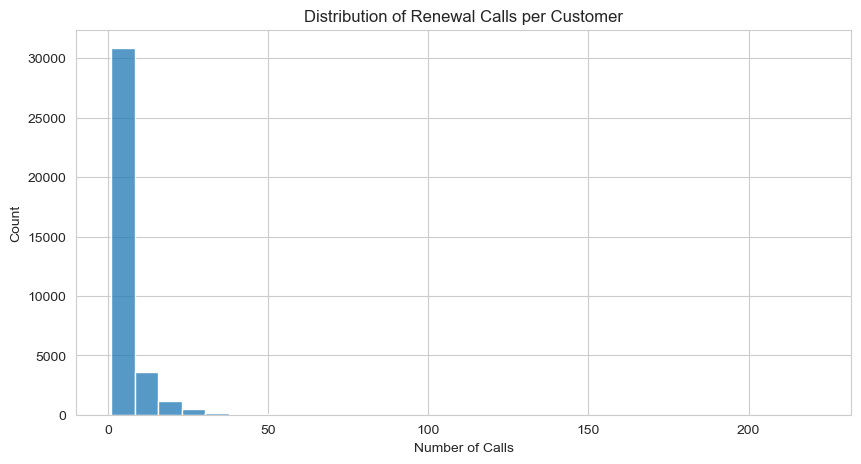

In [52]:
call_counts = renewal_calls["Co_Ref"].value_counts()

plt.figure(figsize=(10,5))
sns.histplot(call_counts, bins=30)
plt.title("Distribution of Renewal Calls per Customer")
plt.xlabel("Number of Calls")
plt.show()

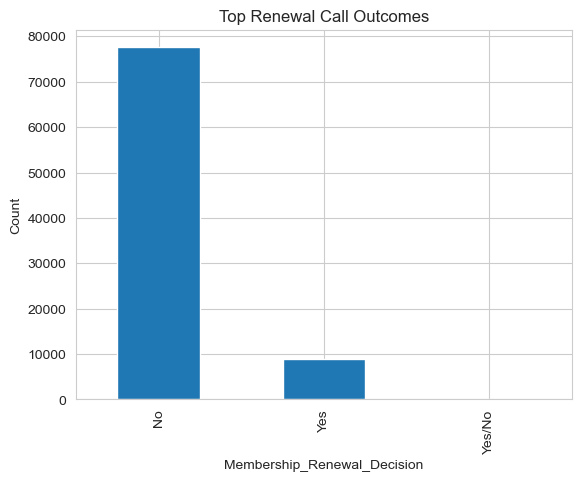

In [60]:
renewal_calls["Membership_Renewal_Decision"].value_counts().head(10).plot(kind="bar")
plt.title("Top Renewal Call Outcomes")
plt.ylabel("Count")
plt.show()

In [61]:
[col for col in renewal_calls.columns if "complaint" in col.lower()]

['Complaint_Category', 'Serious_Complaint', 'Other_Complaint']

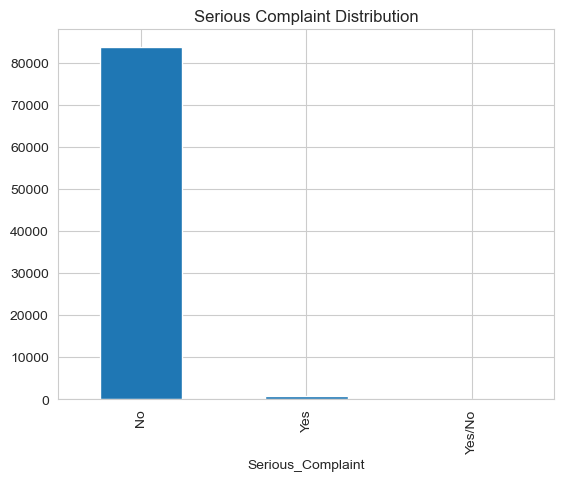

In [62]:
renewal_calls["Serious_Complaint"].value_counts().plot(kind="bar")
plt.title("Serious Complaint Distribution")
plt.show()

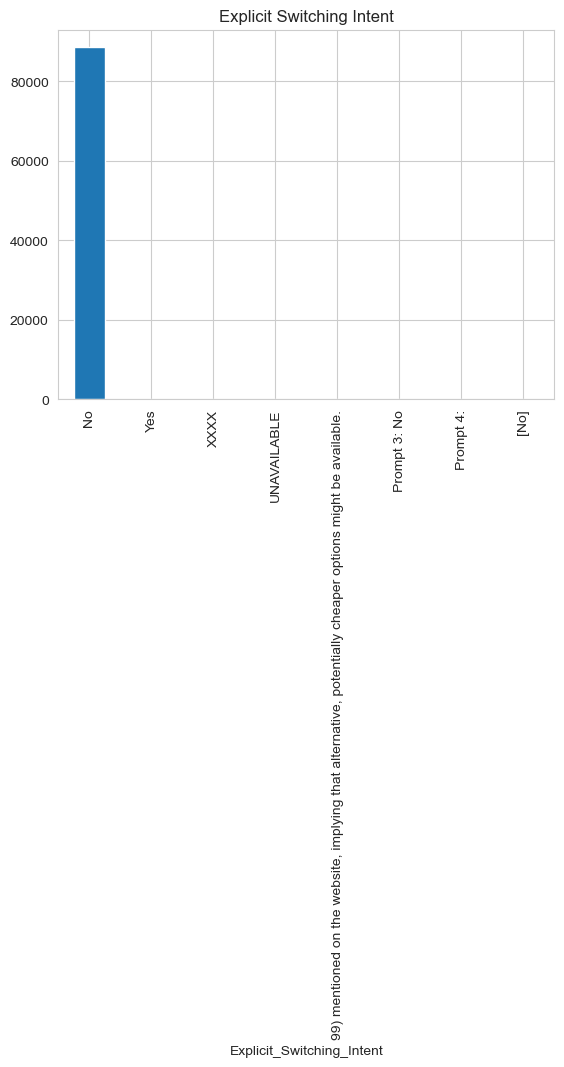

In [65]:
renewal_calls["Explicit_Switching_Intent"].value_counts().plot(kind="bar")
plt.title("Explicit Switching Intent")
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_39580\406294911.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  renewal_calls["Call_Date"] = pd.to_datetime(


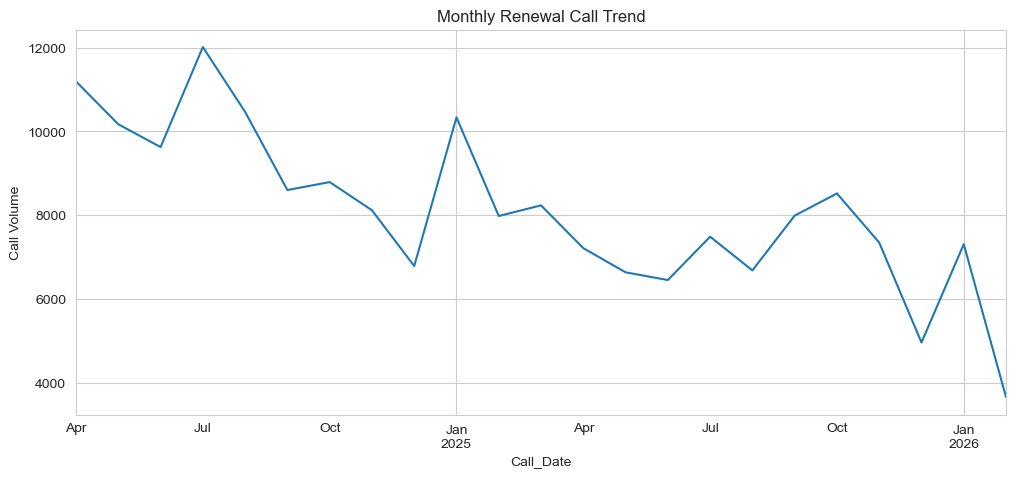

In [64]:
renewal_calls["Call_Date"] = pd.to_datetime(
    renewal_calls["Call_Date"],
    errors="coerce"
)

renewal_calls.groupby(
    renewal_calls["Call_Date"].dt.to_period("M")
).size().plot(figsize=(12,5))

plt.title("Monthly Renewal Call Trend")
plt.ylabel("Call Volume")
plt.show()


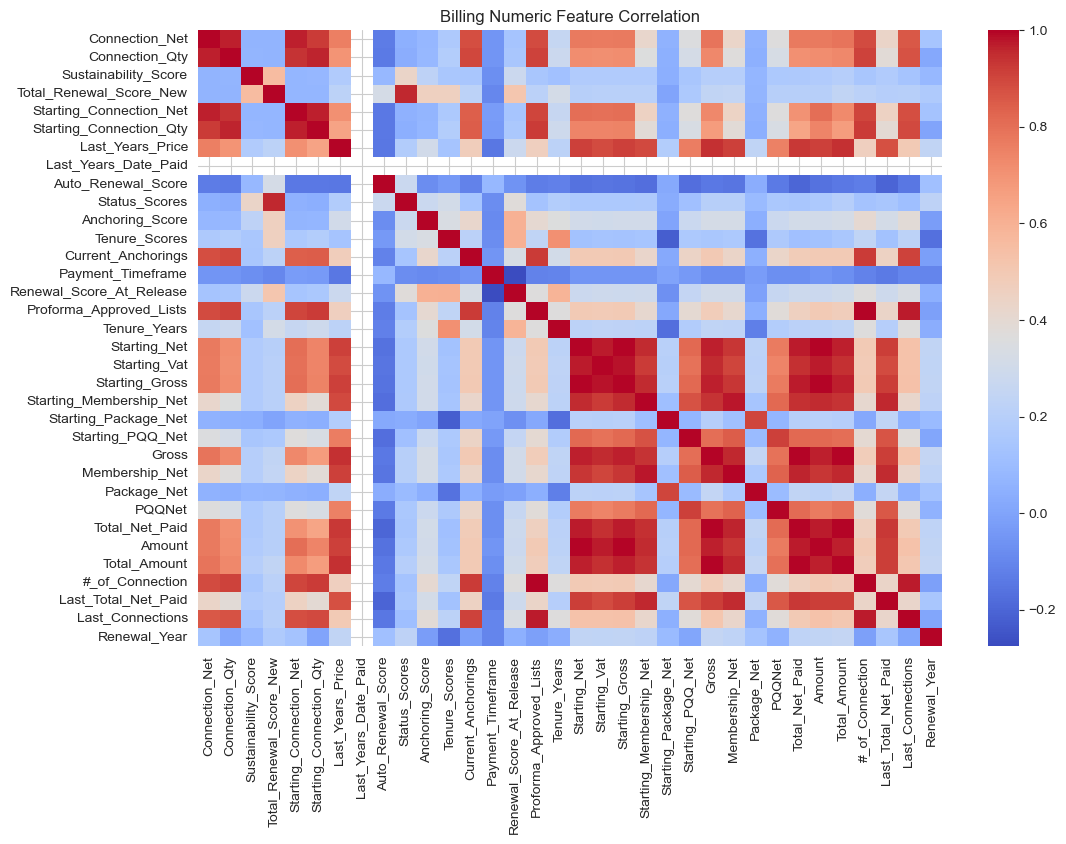

In [67]:
plt.figure(figsize=(12,8))
sns.heatmap(billings.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Billing Numeric Feature Correlation")
plt.show()